In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Reflection

You have a point: 

$$
p = (4, 2)
$$

You need to reflect it across:

- The **x-axis** (horizontal mirror)
- The **y-axis** (vertical mirror)
- The line **$y = x$** (diagonal mirror)
- The line **$y = -x$** (anti-diagonal mirror)

| Reflection Across | Rule | Result |
|-------------------|------|--------|
| **X-Axis** | $(x, y) \rightarrow (x, -y)$ | $(4, -2)$ |
| **Y-Axis** | $(x, y) \rightarrow (-x, y)$ | $(-4, 2)$ |
| **$y = x$** | $(x, y) \rightarrow (y, x)$ | $(2, 4)$ |
| **$y = -x$** | $(x, y) \rightarrow (-y, -x)$ | $(-2, -4)$ |

### Householder Reflection Matrix

$$
R = I - \frac{2vv^T}{v^T v}
$$


**Reflects a vector across a hyperplane defined by vector $v$.**

- **$v$** = The normal vector to the hyperplane (perpendicular to the mirror)
- **$I$** = Identity matrix
- **$R$** = Reflection matrix


| Component | Meaning |
|-----------|---------|
| $v$ | Normal vector to the mirror plane |
| $v^T$ | Transpose of $v$ |
| $v^T v$ | Squared length of $v$ ($\|v\|^2$) |
| $I$ | Identity matrix |

**Mirror:** X-Axis

**Normal Vector:** $v = (0, 1)$

$$
v^T v = 1, \quad vv^T = \begin{bmatrix} 0 & 0 \\ 0 & 1 \end{bmatrix}
$$

$$
R = I - 2 \begin{bmatrix} 0 & 0 \\ 0 & 1 \end{bmatrix}
= \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix} - \begin{bmatrix} 0 & 0 \\ 0 & 2 \end{bmatrix}
= \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}
$$

**Apply to $p = (4, 2)$:**

$$
R \cdot p = \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix} \begin{bmatrix} 4 \\ 2 \end{bmatrix}
= \begin{bmatrix} 4 \\ -2 \end{bmatrix} \quad \checkmark
$$

#### Two Versions of the Householder Formula

| Formula | What it reflects across |
|---------|------------------------|
| $R = I - \frac{2vv^T}{v^T v}$ | Reflects across the **hyperplane orthogonal to $v$**  (normal to mirror)|
| $R = \frac{2vv^T}{v^T v} - I$ | Reflects across the **line spanned by $v$** (direction of mirror)|


Version 1: Hyperplane Reflection (Most Common)

$$
R = I - \frac{2vv^T}{v^T v}
$$

**Reflects across the plane perpendicular to $v$ (normal vector).**

| Mirror | Normal $v$ | Result |
|--------|-----------|--------|
| **X-Axis** | $v = (0, 1)$ | Flip y: $(x, y) \rightarrow (x, -y)$ ✅ |
| **Y-Axis** | $v = (1, 0)$ | Flip x: $(x, y) \rightarrow (-x, y)$ ✅ |

**With $v = (0, 1)$:**
$$
R = I - 2 \begin{bmatrix} 0 & 0 \\ 0 & 1 \end{bmatrix}
= \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}
$$


Version 2: Line Reflection

$$
R = \frac{2vv^T}{v^T v} - I
$$

**Reflects across the line spanned by $v$ (direction vector).**

| Mirror | Direction $v$ | Result |
|--------|--------------|--------|
| **X-Axis** | $v = (1, 0)$ | Flip y: $(x, y) \rightarrow (x, -y)$ ✅ |
| **Y-Axis** | $v = (0, 1)$ | Flip x: $(x, y) \rightarrow (-x, y)$ ✅ |

**With $v = (1, 0)$:**
$$
R = 2 \begin{bmatrix} 1 & 0 \\ 0 & 0 \end{bmatrix} - I
= \begin{bmatrix} 2 & 0 \\ 0 & 0 \end{bmatrix} - \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}
= \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}
$$


In [22]:
# reflect accorss x axis
v = np.array([1, 0]).reshape(2, 1)
I = np.identity(2)

vtv = v.T @ v
vvt = v @ v.T

R = (2 * vvt) / vtv - I
R

array([[ 1.,  0.],
       [ 0., -1.]])

In [25]:
# reflect accorss x axis
v = np.array([1, 0]) 
I = np.identity(2)

vtv = v.T@v
vvt = np.outer(v, v.T) 

R = (2 * vvt) / vtv - I
R

array([[ 1.,  0.],
       [ 0., -1.]])

In [26]:
type(R)

numpy.ndarray

In [39]:
def reflect(p, reflection_vector):
    if isinstance(reflection_vector, list):
        v = np.array(reflection_vector)
    if isinstance(reflection_vector, np.ndarray):
        v = reflection_vector 
        
    I = np.identity(2)
    
    vtv = v.T@v
    vvt = np.outer(v, v.T) 
    
    R = (2 * vvt) / vtv - I
    return R @ p

p = [4, 2]

reflect_accorss_x = reflect(p=p, reflection_vector=[1, 0])
reflect_accorss_y = reflect(p=p, reflection_vector=[0, 1])
reflect_accorss_yx = reflect(p=p, reflection_vector=[1, 1])
reflect_accorss_neg_yx = reflect(p=p, reflection_vector=[-1, 1])

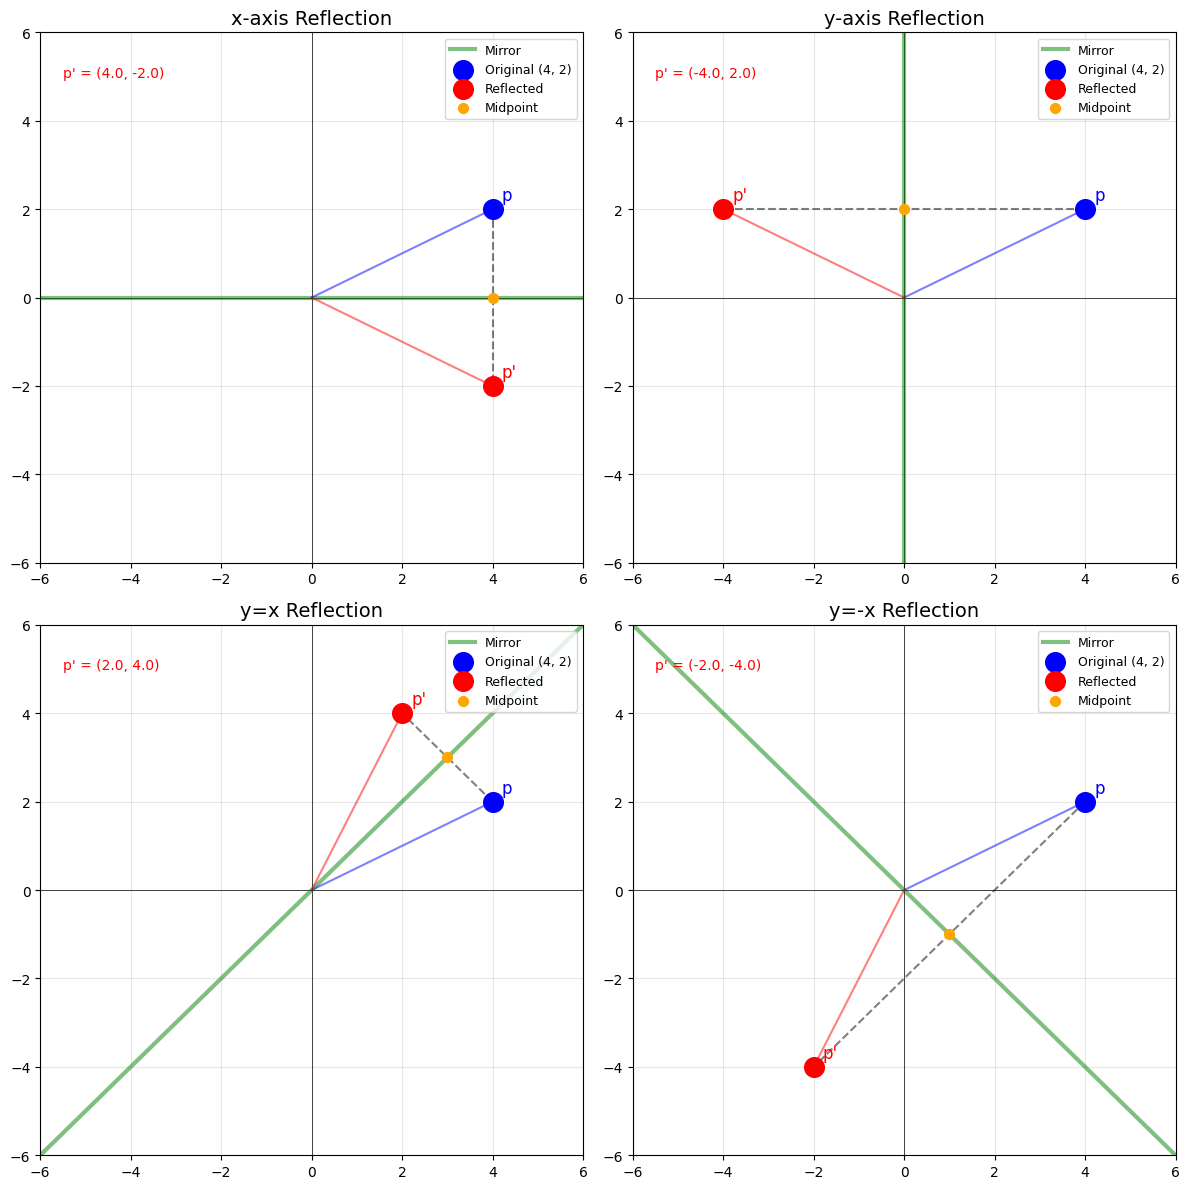

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

reflections_list = [
    (reflect_accorss_x, 'x-axis Reflection', 'x'),
    (reflect_accorss_y, 'y-axis Reflection', 'y'),
    (reflect_accorss_yx, 'y=x Reflection', 'y=x'),
    (reflect_accorss_neg_yx, 'y=-x Reflection', 'y=-x')
]

for ax, (reflected, title, reflection_line) in zip(axes, reflections_list):
    # plot grid
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.set_title(title, fontsize=14)
    
    # mirror line
    if reflection_line == 'x':
        ax.axhline(y=0, color='green', linewidth=3, alpha=0.5, label='Mirror')
        mirror_line = 'y = 0'
    elif reflection_line == 'y':
        ax.axvline(x=0, color='green', linewidth=3, alpha=0.5, label='Mirror')
    elif reflection_line == 'y=x':
        x_vals = np.linspace(-6, 6, 100)
        ax.plot(x_vals, x_vals, 'green', linewidth=3, alpha=0.5, label='Mirror')
    else:  # y=-x
        x_vals = np.linspace(-6, 6, 100)
        ax.plot(x_vals, -x_vals, 'green', linewidth=3, alpha=0.5, label='Mirror')
    
    # original point
    ax.scatter(*p, color='blue', s=200, zorder=5, label='Original (4, 2)')
    ax.text(p[0]+0.2, p[1]+0.2, 'p', color='blue', fontsize=12)
    ax.plot([0, p[0]], [0, p[1]], color='blue', alpha=0.5)
    
    # Plot reflected point
    ax.scatter(*reflected, color='red', s=200, zorder=5, label='Reflected')
    ax.text(reflected[0]+0.2, reflected[1]+0.2, "p'", color='red', fontsize=12)
    ax.plot([0, reflected[0]], [0, reflected[1]], color='red', alpha=0.5)
    
    # dashed line connecting p to p' (perpendicular to mirror)
    ax.plot([p[0], reflected[0]], [p[1], reflected[1]], 'k--', alpha=0.5)
    
    # Mark the midpoint (should lie on mirror line!)
    midpoint = (p + reflected) / 2
    ax.scatter(*midpoint, color='orange', s=50, zorder=6, label='Midpoint')
    
    # Add legend
    ax.legend(loc='upper right', fontsize=9)
    ax.text(-5.5, 5.0, f"p' = ({reflected[0]:.1f}, {reflected[1]:.1f})", fontsize=10, color='red')

plt.tight_layout()
plt.savefig('018_reflection.png', dpi=100)
plt.show()